In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from scipy import stats

In [9]:
df = pd.read_excel("Final_PM15.xlsx")

# Cleaning
df['MDWT'] = pd.to_numeric(df['MDWT'], errors='coerce')
df = df.dropna()

features = [
    '% NBKP',
    'Mean_Load KWH Refiner',
    'Mean_Stock Consistency',
    'Mean_Creping',
    'Mean_Jet Wire Ratio'
]

target = 'MDT'

X = df[features]
y = df[target]

X = sm.add_constant(X)

In [10]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    MDT   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     282.9
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          1.74e-122
Time:                        12:06:09   Log-Likelihood:                -2265.9
No. Observations:                 367   AIC:                             4544.
Df Residuals:                     361   BIC:                             4567.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   1663

## IIDN

In [11]:
residuals = model.resid
fitted = model.fittedvalues

### Normalitas

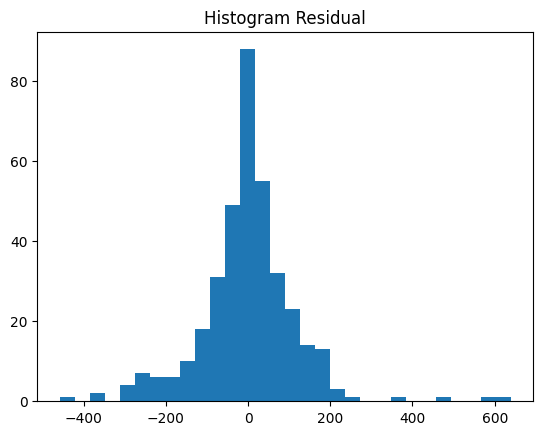

In [12]:
# Histogram
plt.figure()
plt.hist(residuals, bins=30)
plt.title("Histogram Residual")
plt.show()

In [13]:
# P-value > 0.05 = Residual berdistribusi normal
stat, p = stats.shapiro(residuals)
print("Shapiro p-value:", p)

Shapiro p-value: 5.025592978884889e-13


## Independensi (Uji Glejser)

In [14]:
X_glejser = X.copy()   # pakai X yang sama (sudah ada konstanta)

model_glejser = sm.OLS(abs_resid, X_glejser).fit()

glejser_result = pd.DataFrame({
    'Variable': model_glejser.params.index,
    'Coef': model_glejser.params.values,
    'P-value': model_glejser.pvalues.values
})

print(glejser_result)

NameError: name 'abs_resid' is not defined

## Multikolinearitas

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# X sudah termasuk const
def hitung_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                       for i in range(X.shape[1])]
    return vif_data

print(hitung_vif(X))

                  feature           VIF
0                   const  10925.899149
1                  % NBKP      2.733842
2   Mean_Load KWH Refiner      1.166096
3  Mean_Stock Consistency      1.012637
4            Mean_Creping      3.180170
5     Mean_Jet Wire Ratio      1.152311


# new model

In [ ]:
model_robust = sm.OLS(y, X).fit(cov_type='HC3')
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                    MDT   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     253.8
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          8.49e-116
Time:                        12:03:16   Log-Likelihood:                -2265.9
No. Observations:                 367   AIC:                             4544.
Df Residuals:                     361   BIC:                             4567.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   1663

# TRY

HASIL OLS TANPA KOREKSI HETEROSKEDASTISITAS
                            OLS Regression Results                            
Dep. Variable:                    MDT   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     282.9
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          1.74e-122
Time:                        12:06:37   Log-Likelihood:                -2265.9
No. Observations:                 367   AIC:                             4544.
Df Residuals:                     361   BIC:                             4567.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

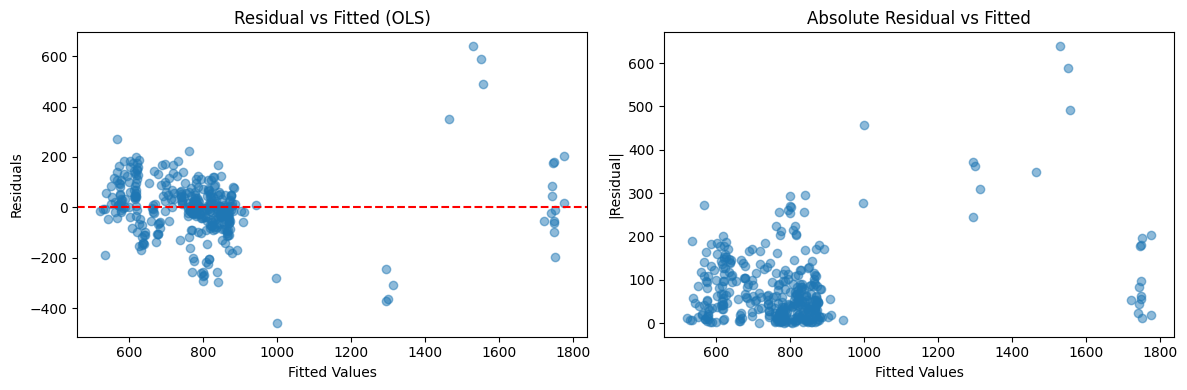


INTERPRETASI FINAL

Berdasarkan hasil di atas:
1. Jika robust standard error berbeda dengan OLS standard error → indikasi heteroskedastisitas
2. Gunakan nilai P-value dari model ROBUST untuk menentukan signifikansi variabel
3. Koefisien regresi tetap sama, hanya standard error yang dikoreksi



In [15]:
# ========================================
# 1. Model OLS yang sudah Anda buat
# ========================================
df = pd.read_excel("Final_PM15.xlsx")

# Cleaning
df['MDWT'] = pd.to_numeric(df['MDWT'], errors='coerce')
df = df.dropna()

features = [
    '% NBKP',
    'Mean_Load KWH Refiner',
    'Mean_Stock Consistency',
    'Mean_Creping',
    'Mean_Jet Wire Ratio'
]

target = 'MDT'

X = df[features]
y = df[target]

X = sm.add_constant(X)

# Model OLS biasa (tanpa koreksi)
model = sm.OLS(y, X).fit()
print("=" * 70)
print("HASIL OLS TANPA KOREKSI HETEROSKEDASTISITAS")
print("=" * 70)
print(model.summary())


# ========================================
# 2. Model dengan Robust Standard Errors (HC3)
# ========================================
print("\n" + "=" * 70)
print("HASIL OLS DENGAN ROBUST STANDARD ERRORS (HC3)")
print("=" * 70)

model_robust = sm.OLS(y, X).fit(cov_type='HC3')
print(model_robust.summary())


# ========================================
# 3. Uji Glejser (Sudah Anda lakukan)
# ========================================
print("\n" + "=" * 70)
print("UJI GLEJSER (HETEROSKEDASTISITAS)")
print("=" * 70)

residuals = model.resid
abs_resid = np.abs(residuals)  # <-- ini yang tadinya undefined

model_glejser = sm.OLS(abs_resid, X).fit()

glejser_result = pd.DataFrame({
    'Variable': model_glejser.params.index,
    'Coef': model_glejser.params.values,
    'P-value': model_glejser.pvalues.values
})
print(glejser_result)

# Kesimpulan Glejser
signif_vars = glejser_result[glejser_result['P-value'] < 0.05]
print(f"\n→ Variabel signifikan (p < 0.05): {len(signif_vars)} dari {len(glejser_result)}")
if len(signif_vars) > 1:  # >1 karena const juga dihitung
    print("→ KESIMPULAN: Heteroskedastisitas TERDETEKSI")
    print("→ Gunakan model_robust untuk interpretasi final")


# ========================================
# 4. Perbandingan Standard Error
# ========================================
print("\n" + "=" * 70)
print("PERBANDINGAN STANDARD ERROR")
print("=" * 70)

comparison = pd.DataFrame({
    'Variable': model.params.index,
    'Coef (OLS)': model.params.values,
    'Std Error (OLS)': model.bse.values,
    'Std Error (Robust)': model_robust.bse.values,
    'P-value (OLS)': model.pvalues.values,
    'P-value (Robust)': model_robust.pvalues.values
})
print(comparison)


# ========================================
# 5. Visualisasi (Opsional)
# ========================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Residual vs Fitted (deteksi heteroskedastisitas visual)
axes[0].scatter(model.fittedvalues, residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual vs Fitted (OLS)')

# Plot 2: Abs Residual vs Fitted
axes[1].scatter(model.fittedvalues, abs_resid, alpha=0.5)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('|Residual|')
axes[1].set_title('Absolute Residual vs Fitted')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("INTERPRETASI FINAL")
print("=" * 70)
print("""
Berdasarkan hasil di atas:
1. Jika robust standard error berbeda dengan OLS standard error → indikasi heteroskedastisitas
2. Gunakan nilai P-value dari model ROBUST untuk menentukan signifikansi variabel
3. Koefisien regresi tetap sama, hanya standard error yang dikoreksi
""")